## Plot function for "Isolate Label Skew Effects"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_label_skew_metric(
    csv_path,
    metric="f1_global_macro",
    beta_q=10.0,
    save_path=None,
):
    """
    Plot performance as a function of beta_L while keeping beta_Q fixed.

    Parameters
    ----------
    csv_path : str
        Path to the summary csv.
    metric : str
        One of:
        - "f1_global_macro"
        - "f1_per_client_macro"
        - "mse_macro"
        - "ece_macro"
    beta_q : float
        Fixed beta_Q value used to isolate label skew effects.
    save_path : str or None
        Optional path to save the figure.
    """

    df = pd.read_csv(csv_path)

    # Filter to isolate label skew effects
    df = df[df["beta_Q"] == beta_q].copy()

    if df.empty:
        raise ValueError(f"No rows found with beta_Q = {beta_q}")

    metric_map = {
        "f1_global_macro": [
            "F1_global_AlveolarOsteitis",
            "F1_global_SecondaryInfection",
            "F1_global_NerveDysesthesia",
            "F1_global_Bleeding",
        ],
        "f1_per_client_macro": [
            "F1_per_client_AlveolarOsteitis",
            "F1_per_client_SecondaryInfection",
            "F1_per_client_NerveDysesthesia",
            "F1_per_client_Bleeding",
        ],
        "mse_macro": [
            "MSE_AlveolarOsteitis",
            "MSE_SecondaryInfection",
            "MSE_NerveDysesthesia",
            "MSE_Bleeding",
        ],
        "ece_macro": [
            "ECE_AlveolarOsteitis",
            "ECE_SecondaryInfection",
            "ECE_NerveDysesthesia",
            "ECE_Bleeding",
        ],
    }

    if metric not in metric_map:
        raise ValueError(
            f"Unknown metric '{metric}'. Choose one of: {list(metric_map.keys())}"
        )

    cols = metric_map[metric]

    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in csv: {missing}")

    # Macro average across complications
    df["plot_metric"] = df[cols].mean(axis=1)

    # Sort values for clean plotting
    df = df.sort_values(["paradigm", "beta_L"])

    ylabel_map = {
        "f1_global_macro": "Macro F1 (global)",
        "f1_per_client_macro": "Macro F1 (per client)",
        "mse_macro": "Macro MSE",
        "ece_macro": "Macro ECE",
    }

    print(df[df["paradigm"]=="local"][["beta_L","plot_metric"]])
    print(df[df["paradigm"]=="centralized"][["beta_L","plot_metric"]])
    plt.figure(figsize=(8, 5))

    for paradigm in df["paradigm"].dropna().unique():
        sub = df[df["paradigm"] == paradigm].sort_values("beta_L")
        plt.plot(sub["beta_L"], sub["plot_metric"], marker="o", label=paradigm)

    plt.xlabel(r"Label skew $\beta_L$")
    plt.ylabel(ylabel_map[metric])
    plt.title(f"{ylabel_map[metric]} vs. $\\beta_L$ (with $\\beta_Q={beta_q}$)")
    plt.legend(title="Paradigm")
    plt.grid(True)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

     beta_L  plot_metric
19      0.1     0.412945
40      0.5     0.393130
61      1.0     0.473887
82      1.5     0.478877
103     2.0     0.483200
124     5.0     0.500246
145    10.0     0.497442
     beta_L  plot_metric
18      0.1     0.610802
39      0.5     0.622685
60      1.0     0.702837
81      1.5     0.748465
102     2.0     0.758528
123     5.0     0.775912
144    10.0     0.772093


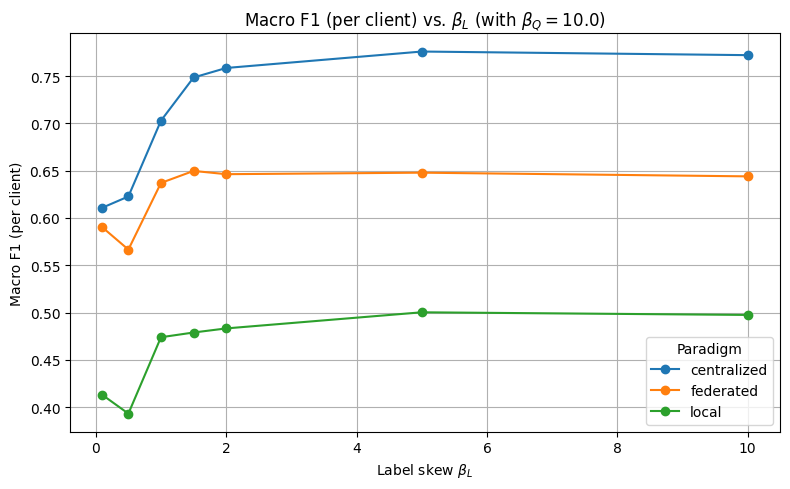

In [3]:
csv_path = r"C:\Users\Oskar\Desktop\Dataproject\federated-dental-risk-vol2\src\fdrp\analysis\Results\sweep_beta_summary_1.csv"
plot_label_skew_metric(csv_path, metric="f1_per_client_macro", beta_q=10.0)

In [8]:
df = pd.read_csv(r"C:\Users\Oskar\Desktop\Dataproject\federated-dental-risk-vol2\src\fdrp\analysis\Results\sweep_beta_summary_1.csv")

df

,paradigm,beta_L,beta_Q,seed,f1_global_macro,f1_per_client_macro,mse_macro,ece_macro,MSE_AlveolarOsteitis,ECE_AlveolarOsteitis,...,F1_global_SecondaryInfection,F1_per_client_SecondaryInfection,F1_global_NerveDysesthesia,F1_per_client_NerveDysesthesia,F1_global_Bleeding,F1_per_client_Bleeding,disagreement_per_client_macro,disagreement_global_macro,fleiss_kappa_per_client_macro,fleiss_kappa_global_macro
0,centralized,0.1,0.1,42,0.760391,0.610802,0.000293,0.002090,0.000668,0.003546,...,0.818698,0.657596,0.649785,0.570929,0.739576,0.592187,0.744083,0.000000,0.487966,1.000000
1,local,0.1,0.1,42,0.340909,0.412945,0.068111,0.150077,0.066109,0.156818,...,0.381631,0.440395,0.254152,0.361604,0.324623,0.393778,0.999667,0.997833,0.156665,0.103675
2,federated,0.1,0.1,42,0.619741,0.590107,0.000595,0.007353,0.001454,0.018781,...,0.726685,0.636909,0.439853,0.541014,0.600797,0.568828,0.728417,0.000000,0.483314,1.000000
3,centralized,0.1,0.5,42,0.760391,0.610802,0.000293,0.002090,0.000668,0.003546,...,0.818698,0.657596,0.649785,0.570929,0.739576,0.592187,0.744083,0.000000,0.487966,1.000000
4,local,0.1,0.5,42,0.340909,0.412945,0.068111,0.150077,0.066109,0.156818,...,0.381631,0.440395,0.254152,0.361604,0.324623,0.393778,0.999667,0.997833,0.156665,0.103675
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,local,10.0,5.0,42,0.426150,0.497442,0.001108,0.004994,0.002104,0.008079,...,0.477590,0.602083,0.285775,0.383183,0.346073,0.377373,0.904167,0.916000,0.362034,0.347690
143,federated,10.0,5.0,42,0.598888,0.643952,0.000562,0.002332,0.001197,0.003950,...,0.732665,0.746404,0.358429,0.514193,0.551959,0.570270,0.201833,0.000000,0.887717,1.000000
144,centralized,10.0,10.0,42,0.760391,0.772093,0.000293,0.002090,0.000668,0.003546,...,0.818698,0.817598,0.649785,0.737566,0.739576,0.718954,0.277083,0.000000,0.842099,1.000000
145,local,10.0,10.0,42,0.426150,0.497442,0.001108,0.004994,0.002104,0.008079,...,0.477590,0.602083,0.285775,0.383183,0.346073,0.377373,0.904167,0.916000,0.362034,0.347690


In [7]:
df.columns

Index(['paradigm', 'beta_L', 'beta_Q', 'seed', 'f1_global_macro',
       'f1_per_client_macro', 'mse_macro', 'ece_macro', 'MSE_AlveolarOsteitis',
       'ECE_AlveolarOsteitis', 'MSE_SecondaryInfection',
       'ECE_SecondaryInfection', 'MSE_NerveDysesthesia',
       'ECE_NerveDysesthesia', 'MSE_Bleeding', 'ECE_Bleeding',
       'F1_global_AlveolarOsteitis', 'F1_per_client_AlveolarOsteitis',
       'F1_global_SecondaryInfection', 'F1_per_client_SecondaryInfection',
       'F1_global_NerveDysesthesia', 'F1_per_client_NerveDysesthesia',
       'F1_global_Bleeding', 'F1_per_client_Bleeding',
       'disagreement_per_client_macro', 'disagreement_global_macro',
       'fleiss_kappa_per_client_macro', 'fleiss_kappa_global_macro'],
      dtype='str')